In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

C:\Users\dirkl\AppData\Local\Temp\ipykernel_11192\164128360.py:4: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("../data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
C:\Users\dirkl\AppData\Local\Temp\ipykernel_11192\164128360.py:4: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("../data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
C:\Users\dirkl\AppData\Local\Temp\ipykernel_11192\164128360.py:4: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("../data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
C:\Users\dirkl\AppData\Local\Temp\ipykernel_11192\164128360.py:4: DtypeWarning: Columns (2,3,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_new = pd.read_csv("../data/n

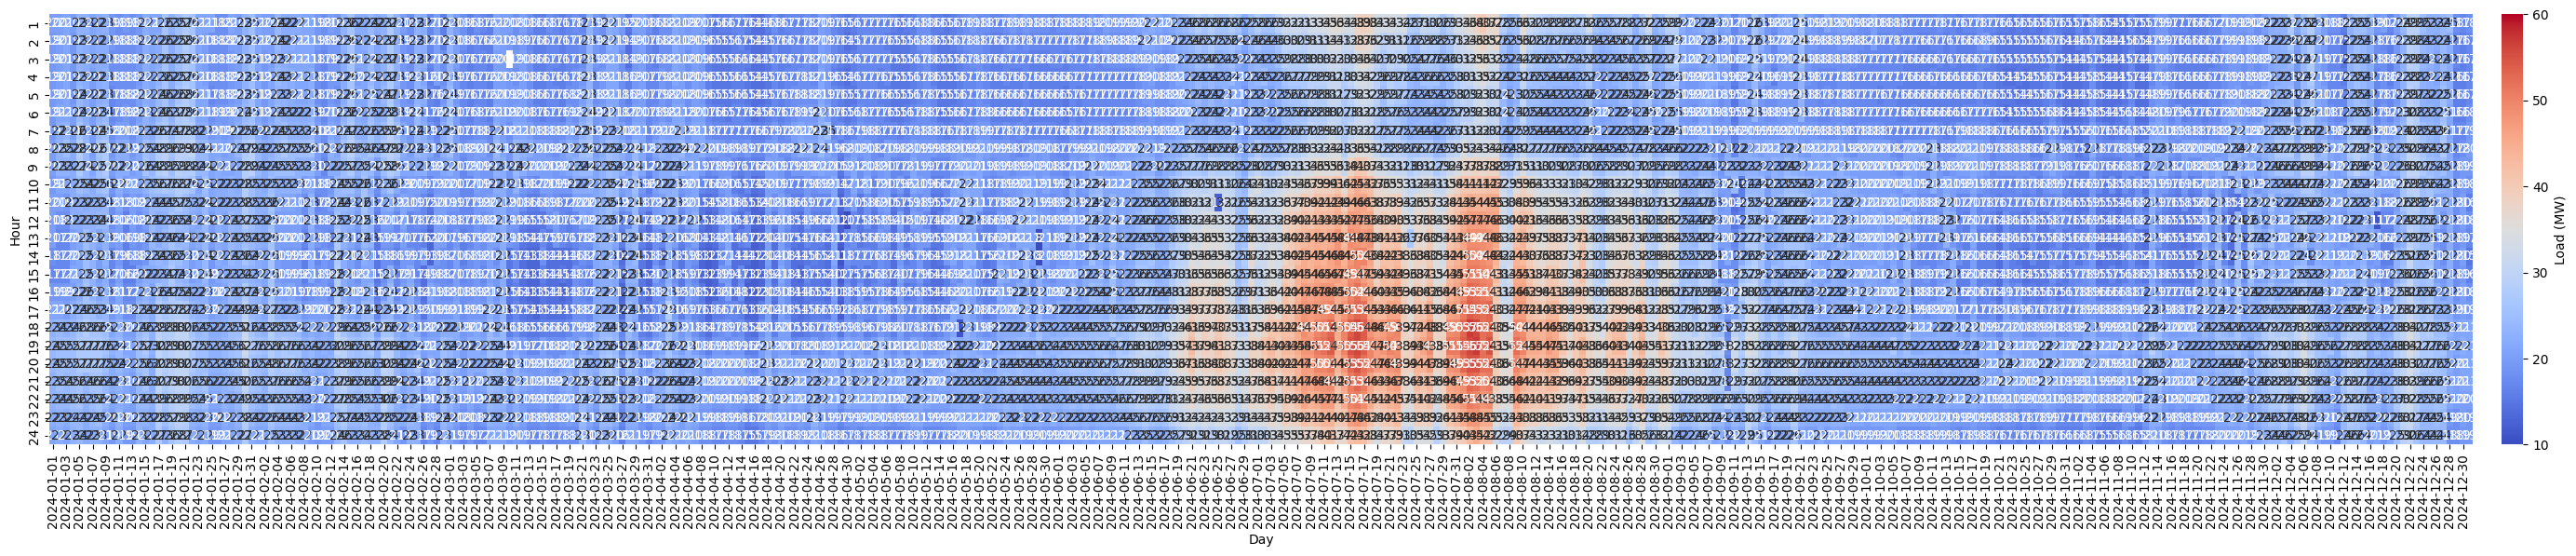

In [67]:
month_list = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
df = []
for mh in month_list:
    df_new = pd.read_csv("../data/nodalloadweights_4006_2024"+mh+".csv", skiprows = 3)
    df_new = df_new[df_new["Network Node Description"] == "LD.CANDLE  13.2"]
    df_new.reset_index(inplace = True, drop = True)
    if len(df) == 0:
        df = df_new
    else:
        df = pd.concat([df, df_new])
df.reset_index(drop = True, inplace = True)
df.drop_duplicates(subset=['Day', 'Hour'], keep = 'first', inplace = True)
df["Hour"] = [int(num) for num in df["Hour"].values]
df["MW Factor"] = [float(num) for num in df["MW Factor"].values]
df["Price"] = [float(num) for num in df["Price"].values]
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(40, 6))
sns.heatmap(hm_load, annot=True, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_spring_24.svg', format='svg')

In [7]:
df.to_csv('Nantucket_2024.csv', index = False)

In [5]:
df = pd.read_csv('../data/Nantucket_2024.csv')

Text(0.5, 0, 'Days with load exceeding')

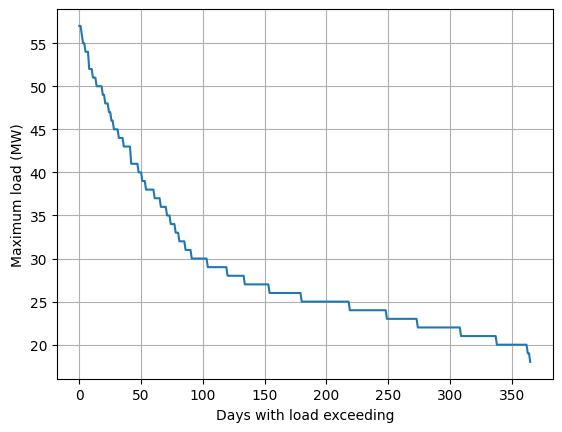

In [20]:
plt.plot(df.groupby('Day')["MW Factor"].max().sort_values(ascending = False).values)
plt.grid()
plt.ylabel('Maximum load (MW)')
plt.xlabel('Days with load exceeding')

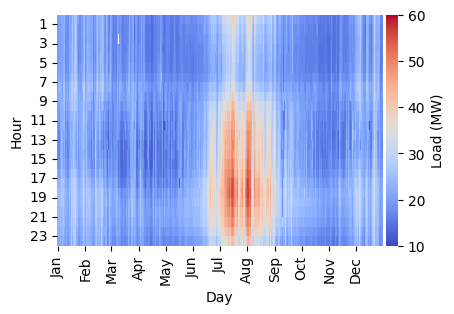

In [6]:
hm_load = df.pivot(index = "Hour", columns = "Day", values = "MW Factor")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_load, annot=False, cmap='coolwarm', cbar_kws={'label': 'Load (MW)', "pad": 0.01}, vmin = 10, vmax = 60)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('load_24.svg', format='svg', bbox_inches = 'tight')
plt.savefig('load_24.pdf', format='pdf', bbox_inches = 'tight')

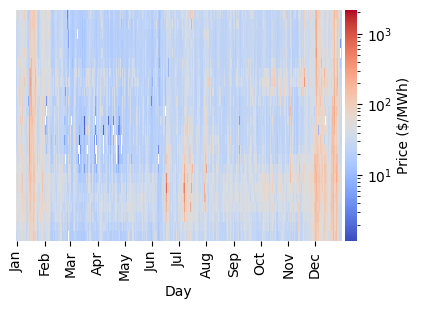

In [61]:
hm_price = df.pivot(index = "Hour", columns = "Day", values = "Price")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, norm = LogNorm(), yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmin = 0.001)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('price_24.svg', format='svg', bbox_inches = 'tight')
plt.savefig('price_24.pdf', format='pdf', bbox_inches = 'tight')

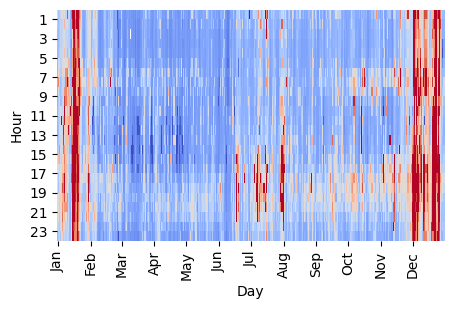

In [70]:
hm_price = df.pivot(index = "Hour", columns = "Day", values = "Price")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': '', "pad": 0.01}, vmin = 0, vmax = 100, cbar = False)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('Hour')
plt.savefig('price_24_hours.svg', format='svg', bbox_inches = 'tight')
plt.savefig('price_24_hours.pdf', format='pdf', bbox_inches = 'tight')

Cambium data for 131 MA (https://scenarioviewer.nrel.gov/?project=0f92fe57-3365-428a-8fe8-0afc326b3b43&mode=download&layout=Default)

In [72]:
cb25 = pd.read_csv("../data/Cambium23_MidCase_hourly_p131_2025.csv", skiprows=5)
cb50 = pd.read_csv("../data/Cambium23_MidCase_hourly_p131_2050.csv", skiprows=5)
dt = pd.to_datetime(cb25.timestamp)
p25 = cb25.energy_cost_busbar
p50 = cb50.energy_cost_busbar
cb = pd.DataFrame({"dt": dt, "hour": dt.dt.hour, "day_of_year": dt.dt.dayofyear, "p25": p25, "p50": p50})

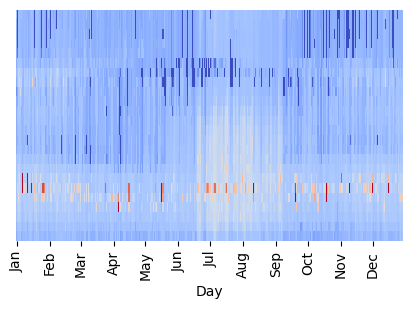

In [73]:
hm_price = cb.pivot(index = "hour", columns = "day_of_year", values = "p25")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmin = 0, vmax = 100, cbar = False)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('cambium_25.svg', format='svg', bbox_inches = 'tight')
plt.savefig('cambium_25.pdf', format='pdf', bbox_inches = 'tight')

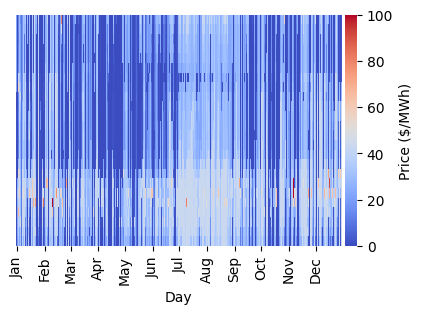

In [76]:
hm_price = cb.pivot(index = "hour", columns = "day_of_year", values = "p50")
# Plot the heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(hm_price, yticklabels = False, annot=False, cmap='coolwarm', cbar_kws={'label': 'Price ($/MWh)', "pad": 0.01}, vmax = 100)
plt.xticks(ticks=np.cumsum([1,31,29,31,30,31,30,31,31,30,31,30]), labels = ["Jan", "Feb", "Mar", "Apr", "May", 
                                                                            "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
#plt.yticks(ticks=np.arange(1,24,2), labels = np.arange(1,24,2), rotation = 0)
plt.xlabel('Day')
plt.ylabel('')
plt.savefig('cambium_50.svg', format='svg', bbox_inches = 'tight')
plt.savefig('cambium_50.pdf', format='pdf', bbox_inches = 'tight')